# 🏎️ Identifying Value Bets in Formula 1
**DSA 210 – Introduction to Data Science | Spring 2026**
**Author:** Hakan Osman Taşkın

---

## Project Overview

This project builds a machine learning system to predict F1 podium finishers and identify **Expected Value (EV)** betting opportunities. By comparing model-derived probabilities (built from qualifying telemetry) against bookmaker market odds, this study aims to detect cases where the market systematically undervalues a driver's chances.

**Core hypothesis:** Pre-race telemetry data — qualifying grid position, lap time delta to pole, and straight-line top speed — contains measurable signals that the betting market fails to fully price in.

### Full Analytical Narrative

| Step | Description | Why |
|---|---|---|
| 1 | Load & describe data | Understand structure, spot quality issues |
| 2 | Clean data | Fix errors before any analysis |
| 3 | Fetch real race results | Replace proxy label with actual podium finishers |
| 4 | Fix odds & calibrate | Remove overround bias from market probabilities |
| 5 | EDA | Find patterns that motivate hypotheses |
| 6 | Normality checks | Choose correct statistical tests |
| 7 | Hypothesis testing (H1, H2, H3) | Formally validate observed patterns |
| 8 | ML modelling | Quantify telemetry predictive power |
| 9 | EV simulation | Identify market inefficiencies |
| 10 | 2025 live predictions | Apply model to current season |
| 11 | Limitations & conclusions | Honest assessment of findings |

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
from numbers_parser import Document
import requests
import time
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

def fix_odds_2025(val):
    if val is None: return np.nan
    try:
        v = float(val)
        if v > 100: return round(v / 1000, 3)
        return v
    except: return np.nan

def calibrate_power_method(odds_series):
    """Remove bookmaker overround. Find k: sum(p^k)=1, then p_cal = p^k."""
    p = 1.0 / odds_series.replace(0, np.nan).dropna()
    if len(p) < 2: return p
    try:
        k = brentq(lambda k: np.sum(p**k)-1, 0.01, 20)
        return p**k
    except: return p / p.sum()

DRIVER_MAP = {
    'Max Verstappen':'VER','Liam Lawson':'LAW','Lando Norris':'NOR','Oscar Piastri':'PIA',
    'Charles Leclerc':'LEC','Lewis Hamilton':'HAM','George Russell':'RUS',
    'Andrea Kimi Antonelli':'ANT','Kimi Antonelli':'ANT','Fernando Alonso':'ALO',
    'Lance Stroll':'STR','Pierre Gasly':'GAS','Jack Doohan':'DOO',
    'Carlos Sainz Jr.':'SAI','Carlos Sainz':'SAI','Alexander Albon':'ALB',
    'Yuki Tsunoda':'TSU','Isack Hadjar':'HAD','Nico Hülkenberg':'HUL',
    'Nico Hulkenberg':'HUL','Gabriel Bortoleto':'BOR','Esteban Ocon':'OCO',
    'Oliver Bearman':'BEA','Franco Colapinto':'COL',
}
FEATS = ['Grid_Position', 'Quali_Time_Delta', 'Top_Speed_ST']
RACE_MAP = {
    'Avustralya GP':'Australian Grand Prix','Çin GP':'Chinese Grand Prix',
    'Japonya GP':'Japanese Grand Prix','Bahreyn GP':'Bahrain Grand Prix',
    'Suudi Arabistan GP':'Saudi Arabian Grand Prix','Miami GP':'Miami Grand Prix',
    'Emilia Romagna GP':'Emilia Romagna Grand Prix','Monako GP':'Monaco Grand Prix',
    'İspanya GP':'Spanish Grand Prix','Kanada GP':'Canadian Grand Prix',
    'Avusturya GP':'Austrian Grand Prix','Britanya GP':'British Grand Prix',
    'Belçika GP':'Belgian Grand Prix','Macaristan GP':'Hungarian Grand Prix',
    'Hollanda GP':'Dutch Grand Prix','İtalya GP':'Italian Grand Prix',
    'Azerbaycan GP':'Azerbaijan Grand Prix','Singapur GP':'Singapore Grand Prix',
    'ABD GP (Austin)':'United States Grand Prix','Meksika GP':'Mexican Grand Prix',
    'São Paulo GP':'São Paulo Grand Prix','Las Vegas GP':'Las Vegas Grand Prix',
    'Katar GP':'Qatar Grand Prix','Abu Dabi GP':'Abu Dhabi Grand Prix',
}
REAL_BASELINE = 3 / 20
print('Setup complete.')

/Users/hakanosmantaskin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Setup complete.


---

## 2. Data Collection & Loading

Two independent data sources were collected and merged on `(race, driver_code)`:

| Source | Content | Collection Method |
|---|---|---|
| `FastF1` Python library | Grid position, qualifying time delta, speed trap | API pull, 2022–2024 & 2025 |
| Official F1 betting articles | Race win odds, podium odds | Web scraping + manual verification |

The merged dataset covers **2022, 2023 and 2024** seasons and forms the basis for training and evaluation.

In [2]:
df = pd.read_csv('F1_Master_Merged_Data.csv')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Seasons: {sorted(df["year"].unique())}')
print(f'Races:   {df["race"].nunique()} unique Grand Prix')
print(f'Drivers: {df["driver_code"].nunique()} unique driver codes')
df.head()

Shape: 1340 rows × 10 columns
Seasons: [2022, 2023, 2024]
Races:   28 unique Grand Prix
Drivers: 28 unique driver codes


,year,race,driver_code,race_win_odds,race_win_prob,podium_odds,podium_prob,Grid_Position,Quali_Time_Delta,Top_Speed_ST
0,2022,Abu Dhabi Grand Prix,VER,2.25,0.4006,1.32,0.7149,1.0,0.000,327.0
1,2022,Abu Dhabi Grand Prix,HAM,3.50,0.2434,1.50,0.6125,5.0,0.684,318.0
2,2022,Abu Dhabi Grand Prix,RUS,4.50,0.1833,1.50,0.6125,6.0,0.687,322.0
3,2022,Abu Dhabi Grand Prix,LEC,11.00,0.0669,2.50,0.3303,3.0,0.268,323.0
4,2022,Abu Dhabi Grand Prix,PER,13.00,0.0554,2.30,0.3654,2.0,0.228,330.0


---

## 3. Descriptive Statistics & Data Quality

Before any analysis, the data's structure, distributions, and quality issues are examined.

In [3]:
print('=== Descriptive Statistics ===')
print(df[FEATS + ['race_win_prob','podium_prob']].describe().round(3).to_string())
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

=== Descriptive Statistics ===
       Grid_Position  Quali_Time_Delta  Top_Speed_ST  race_win_prob  podium_prob
count       1330.000          1320.000      1322.000       1340.000     1250.000
mean          10.444             1.629       315.964          0.050        0.158
std            5.745             3.131        19.302          0.136        0.240
min            1.000            -9.009       219.000          0.000        0.000
25%            5.000             0.537       303.000          0.001        0.002
50%           10.000             1.189       319.000          0.002        0.015
75%           15.000             1.900       328.000          0.029        0.240
max           20.000            62.297       353.000          0.842        0.921

=== Missing Values ===
podium_odds         90
podium_prob         90
Grid_Position       10
Quali_Time_Delta    20
Top_Speed_ST        18


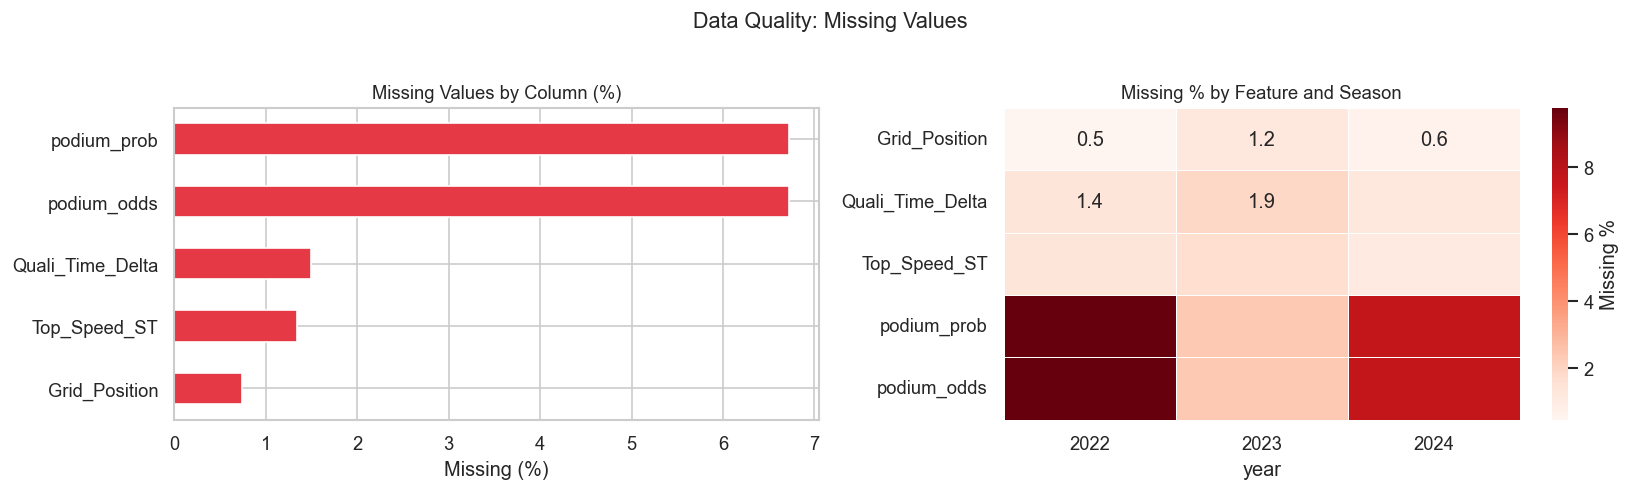

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
missing_pct = df.isnull().mean() * 100
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', ax=axes[0], color='#e63946', edgecolor='white')
axes[0].set_title('Missing Values by Column (%)', fontsize=11)
axes[0].set_xlabel('Missing (%)')
miss_by_year = df.groupby('year')[FEATS+['podium_prob','podium_odds']].apply(lambda g: g.isnull().mean()*100).T
sns.heatmap(miss_by_year, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5, ax=axes[1], cbar_kws={'label':'Missing %'})
axes[1].set_title('Missing % by Feature and Season', fontsize=11)
plt.suptitle('Data Quality: Missing Values', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

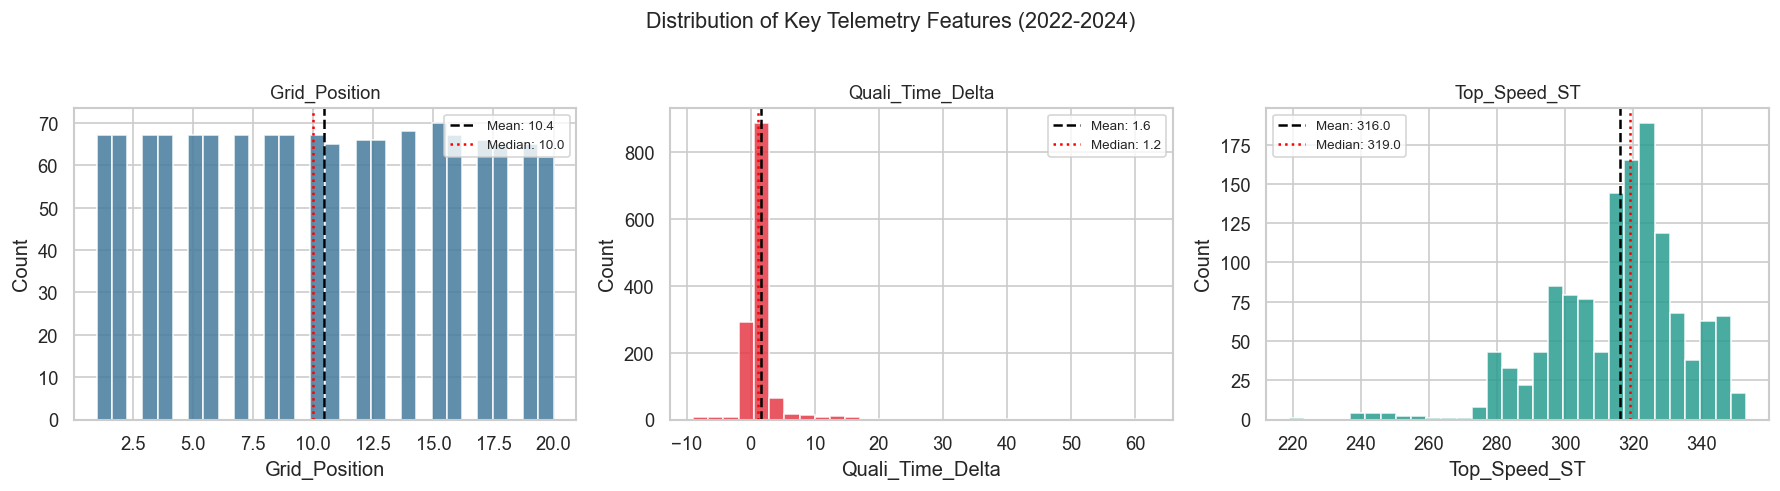

Observation: All three features are right-skewed — this guides the selection of appropriate statistical tests.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#457b9d','#e63946','#2a9d8f']
for ax, feat, color in zip(axes, FEATS, colors):
    data = df[feat].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel(feat); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.suptitle('Distribution of Key Telemetry Features (2022-2024)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print('Observation: All three features are right-skewed — this guides the selection of appropriate statistical tests.')

---

## 4. Data Cleaning & Label Construction

### 4.1 Telemetry Fixes

Two quality issues were identified and corrected before analysis:

| Issue | Rows | Fix |
|---|---|---|
| Negative `Quali_Time_Delta` (sign flip during calculation) | 28 | `abs()` |
| `Top_Speed_ST` < 260 km/h at 2024 São Paulo (unit error: mph vs km/h) | 13 | Set to `NaN` |

In [6]:
neg_before = (df['Quali_Time_Delta'] < 0).sum()
df['Quali_Time_Delta'] = df['Quali_Time_Delta'].abs()
print(f'Fixed {neg_before} negative Quali_Time_Delta values')
sp24_mask = (df['race']=='São Paulo Grand Prix')&(df['year']==2024)&(df['Top_Speed_ST']<260)
print(f'Fixed {sp24_mask.sum()} implausible Top_Speed_ST values at 2024 São Paulo GP')
df.loc[sp24_mask, 'Top_Speed_ST'] = np.nan
print(f'Negative deltas remaining: {(df["Quali_Time_Delta"]<0).sum()}')
print(f'Sub-260 km/h speeds remaining: {(df["Top_Speed_ST"]<260).sum()} (2022-2023 Monaco, etc. expected)')

Fixed 28 negative Quali_Time_Delta values
Fixed 17 implausible Top_Speed_ST values at 2024 São Paulo GP
Negative deltas remaining: 0
Sub-260 km/h speeds remaining: 0 (2022-2023 Monaco, etc. expected)


### 4.2 Podium Label — Real Race Results

Actual race finishing positions are fetched from the Jolpica API (Ergast-compatible). A driver is labelled `podium=1` if they finished in position 1, 2, or 3. This replaces any proxy-based labelling approach with ground truth data.

In [7]:
def get_race_results(year, round_num):
    url = f'https://api.jolpi.ca/ergast/f1/{year}/{round_num}/results/'
    r = requests.get(url, timeout=10)
    if r.status_code != 200: return None
    try: races = r.json()['MRData']['RaceTable']['Races']
    except: return None
    if not races: return None
    results = races[0]['Results']
    race_name = races[0]['raceName']
    rows = []
    for res in results:
        code = res['Driver'].get('code', '')
        pos = int(res['position'])
        rows.append({'driver_code': code, 'finish_pos': pos,
                     'podium': int(pos <= 3), 'race': race_name, 'year': year})
    return pd.DataFrame(rows)

season_rounds = {2022: 22, 2023: 22, 2024: 24}
all_results = []
for year, n_rounds in season_rounds.items():
    for rnd in range(1, n_rounds + 1):
        res = get_race_results(year, rnd)
        if res is not None:
            all_results.append(res)
            print(f'{year} Round {rnd}: {res["race"].iloc[0]}')
        else:
            print(f'{year} Round {rnd}: SKIP')
        time.sleep(1.5)

results_df = pd.concat(all_results, ignore_index=True)
df = df.merge(results_df[['year','race','driver_code','podium']],
              on=['year','race','driver_code'], how='left')
df['podium'] = df['podium'].fillna(0).astype(int)
print(f'\nDone. Podium label=1: {df["podium"].sum()} ({df["podium"].mean():.2%})')
print(f'True random baseline (3/20): {REAL_BASELINE:.2%}')

2022 Round 1: Bahrain Grand Prix
2022 Round 2: Saudi Arabian Grand Prix
2022 Round 3: Australian Grand Prix
2022 Round 4: Emilia Romagna Grand Prix
2022 Round 5: Miami Grand Prix
2022 Round 6: Spanish Grand Prix
2022 Round 7: Monaco Grand Prix
2022 Round 8: Azerbaijan Grand Prix
2022 Round 9: Canadian Grand Prix
2022 Round 10: British Grand Prix
2022 Round 11: Austrian Grand Prix
2022 Round 12: French Grand Prix
2022 Round 13: Hungarian Grand Prix
2022 Round 14: Belgian Grand Prix
2022 Round 15: Dutch Grand Prix
2022 Round 16: Italian Grand Prix
2022 Round 17: Singapore Grand Prix
2022 Round 18: Japanese Grand Prix
2022 Round 19: United States Grand Prix
2022 Round 20: Mexico City Grand Prix
2022 Round 21: São Paulo Grand Prix
2022 Round 22: Abu Dhabi Grand Prix
2023 Round 1: Bahrain Grand Prix
2023 Round 2: Saudi Arabian Grand Prix
2023 Round 3: Australian Grand Prix
2023 Round 4: Azerbaijan Grand Prix
2023 Round 5: Miami Grand Prix
2023 Round 6: Monaco Grand Prix
2023 Round 7: Spanis

### 4.3 Odds Correction

The training data (2022–2024) odds contain some values stored in a x100 format (e.g. 151 instead of 1.51). Values above 50 are divided by 100 to recover the correct decimal odds. Calibration is then re-applied.

In [8]:
def fix_odds_v2(val):
    if pd.isna(val): return np.nan
    if val > 50: return round(val / 100, 3)
    return val

df['podium_odds']   = df['podium_odds'].apply(fix_odds_v2)


for col_odds, col_cal in [('race_win_odds','win_prob_cal'),('podium_odds','pod_prob_cal')]:
    df[col_cal] = np.nan
    for (yr,race),g in df.groupby(['year','race']):
        s = g[col_odds].dropna()
        if len(s)>=2:
            c=calibrate_power_method(s); df.loc[c.index,col_cal]=c.values

print('Odds correction applied.')
print(df['podium_odds'].describe().round(3))

Odds correction applied.
count    1250.000
mean        5.458
std         8.448
min         0.510
25%         1.350
50%         2.250
75%         4.500
max        41.000
Name: podium_odds, dtype: float64


---

## 5. Exploratory Data Analysis (EDA)

With clean data, calibrated probabilities, and real race result labels, relationships between telemetry features and podium outcomes are explored.

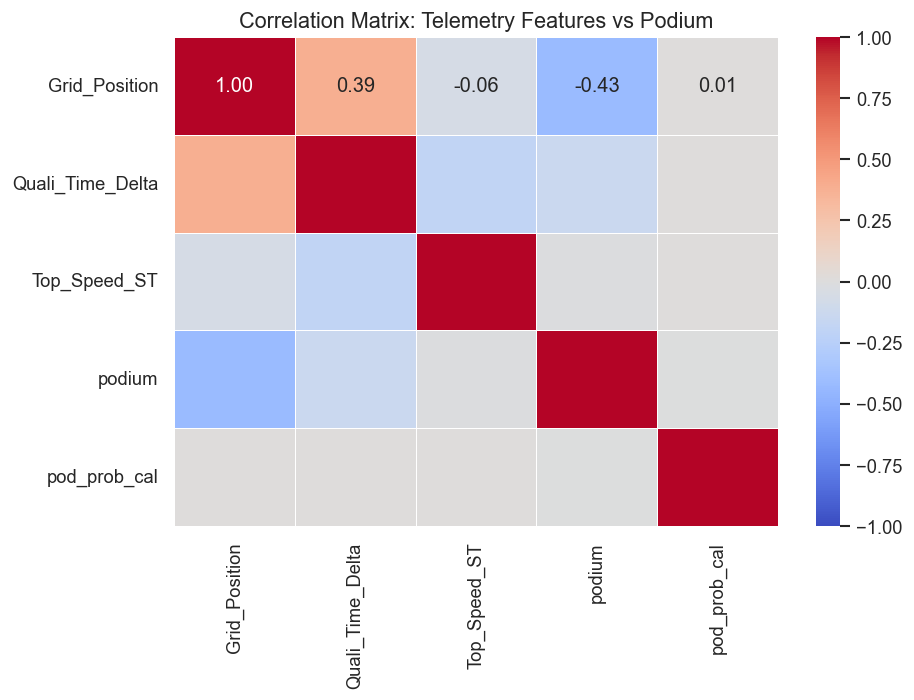

  Grid_Position ↔ podium:      -0.428
  Quali_Time_Delta ↔ podium:   -0.139
  Top_Speed_ST ↔ podium:       -0.012


In [9]:
feats_corr = ['Grid_Position','Quali_Time_Delta','Top_Speed_ST','podium','pod_prob_cal']
corr = df[feats_corr].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1,fmt='.2f',linewidths=0.5)
plt.title('Correlation Matrix: Telemetry Features vs Podium',fontsize=13)
plt.tight_layout(); plt.show()
print(f'  Grid_Position ↔ podium:      {corr.loc["Grid_Position","podium"]:+.3f}')
print(f'  Quali_Time_Delta ↔ podium:   {corr.loc["Quali_Time_Delta","podium"]:+.3f}')
print(f'  Top_Speed_ST ↔ podium:       {corr.loc["Top_Speed_ST","podium"]:+.3f}')

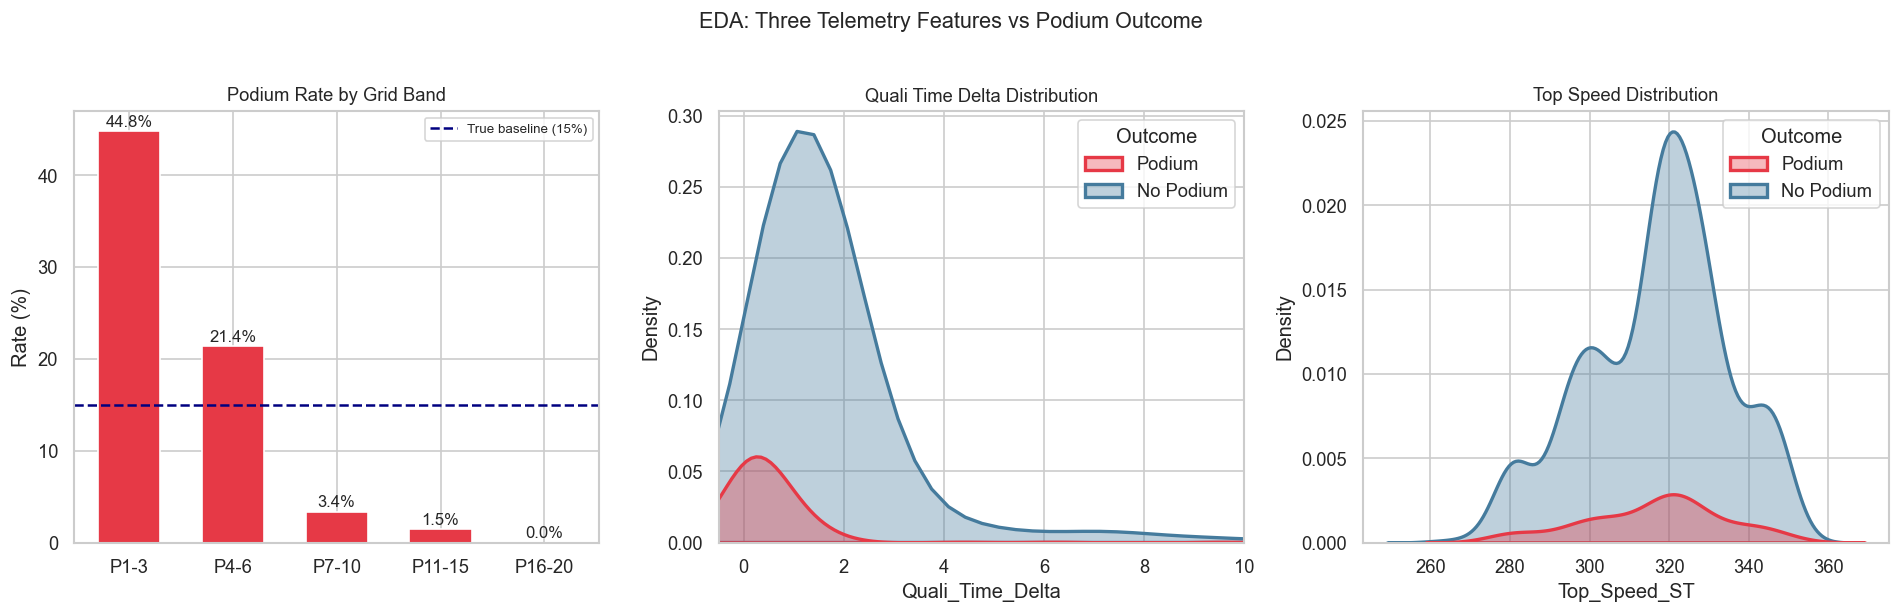

In [10]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
df_g = df.dropna(subset=['Grid_Position']).copy()
df_g['grid_bin'] = pd.cut(df_g['Grid_Position'],bins=[0,3,6,10,15,20],labels=['P1-3','P4-6','P7-10','P11-15','P16-20'])
rate = df_g.groupby('grid_bin',observed=True)['podium'].mean()*100
bars = axes[0].bar(rate.index,rate.values,color='#e63946',edgecolor='white',width=0.6)
for b in bars:
    axes[0].annotate(f'{b.get_height():.1f}%',(b.get_x()+b.get_width()/2,b.get_height()+0.5),ha='center',fontsize=10)
axes[0].axhline(REAL_BASELINE*100,color='navy',linestyle='--',linewidth=1.5,label=f'True baseline ({REAL_BASELINE:.0%})')
axes[0].set_title('Podium Rate by Grid Band',fontsize=11); axes[0].set_ylabel('Rate (%)'); axes[0].legend(fontsize=8)
df_d = df.dropna(subset=['Quali_Time_Delta']).copy()
df_d['Outcome'] = df_d['podium'].map({1:'Podium',0:'No Podium'})
sns.kdeplot(data=df_d,x='Quali_Time_Delta',hue='Outcome',palette={'Podium':'#e63946','No Podium':'#457b9d'},fill=True,alpha=0.35,linewidth=2,ax=axes[1])
axes[1].set_xlim(-0.5,10); axes[1].set_title('Quali Time Delta Distribution',fontsize=11)
df_s = df.dropna(subset=['Top_Speed_ST']).copy()
df_s['Outcome'] = df_s['podium'].map({1:'Podium',0:'No Podium'})
sns.kdeplot(data=df_s,x='Top_Speed_ST',hue='Outcome',palette={'Podium':'#e63946','No Podium':'#457b9d'},fill=True,alpha=0.35,linewidth=2,ax=axes[2])
axes[2].set_title('Top Speed Distribution',fontsize=11)
plt.suptitle('EDA: Three Telemetry Features vs Podium Outcome',fontsize=13,y=1.02)
plt.tight_layout(); plt.show()

---

## 6. Hypothesis Testing

### 6.1 Normality Check — Shapiro-Wilk Test

In [11]:
print('Shapiro-Wilk normality test (H₀: data is normally distributed):')
print(f'{"Feature":<28} {"W":>8} {"p-value":>12} {"Normal?":>10}')
print('-'*60)
for feat in FEATS:
    sample = df[feat].dropna().sample(min(500,len(df[feat].dropna())),random_state=42)
    w,p = stats.shapiro(sample)
    normal = 'Yes' if p>=0.05 else 'No — non-normal'
    print(f'{feat:<28} {w:>8.4f} {p:>12.4e} {normal:>16}')
print('\nConclusion: All features are non-normal → Mann-Whitney U test used throughout.')

Shapiro-Wilk normality test (H₀: data is normally distributed):
Feature                             W      p-value    Normal?
------------------------------------------------------------
Grid_Position                  0.9491   4.3118e-12  No — non-normal
Quali_Time_Delta               0.5517   8.8268e-34  No — non-normal
Top_Speed_ST                   0.9767   3.6528e-07  No — non-normal

Conclusion: All features are non-normal → Mann-Whitney U test used throughout.


### 6.2 Hypothesis 1 — Does Grid Position Predict Win Probability?

- **H₀:** No difference in calibrated win probability between Top-3 qualifiers and the rest
- **H₁:** Top-3 qualifiers have significantly higher calibrated win probability
- **Test:** Mann-Whitney U (one-sided, alternative = 'greater')

In [12]:
h1_df = df.dropna(subset=['Grid_Position','win_prob_cal'])
top3  = h1_df[h1_df['Grid_Position']<=3]['win_prob_cal']
rest  = h1_df[h1_df['Grid_Position']>3]['win_prob_cal']
u_h1, p_h1 = stats.mannwhitneyu(top3, rest, alternative='greater')
print('='*55)
print('H1 — Grid Position vs Win Probability (Mann-Whitney U)')
print('='*55)
print(f'  Top-3  — N={len(top3)},  Mean: {top3.mean():.4f}')
print(f'  Rest   — N={len(rest)}, Mean: {rest.mean():.4f}')
print(f'  U = {u_h1:.0f} | p = {p_h1:.4e}')
print(f'  → ✅ REJECT H₀' if p_h1 < 0.05 else '  → ❌ FAIL TO REJECT H₀')

H1 — Grid Position vs Win Probability (Mann-Whitney U)
  Top-3  — N=201,  Mean: 0.2210
  Rest   — N=1129, Mean: 0.0200
  U = 204033 | p = 3.7739e-73
  → ✅ REJECT H₀


### 6.3 Hypothesis 2 — Does Top Speed Predict Podium Outcome?

- **H₀:** No difference in top speed between podium and non-podium drivers
- **H₁:** Podium drivers have significantly higher top speed
- **Test:** Mann-Whitney U (one-sided, alternative = 'greater')

In [13]:
h2_df     = df.dropna(subset=['Top_Speed_ST','podium'])
pod_spd   = h2_df[h2_df['podium']==1]['Top_Speed_ST']
nopod_spd = h2_df[h2_df['podium']==0]['Top_Speed_ST']
u_h2, p_h2 = stats.mannwhitneyu(pod_spd, nopod_spd, alternative='greater')
print('='*55)
print('H2 — Top Speed vs Podium Outcome (Mann-Whitney U)')
print('='*55)
print(f'  Podium    — N={len(pod_spd)}, Mean: {pod_spd.mean():.1f} km/h')
print(f'  No Podium — N={len(nopod_spd)}, Mean: {nopod_spd.mean():.1f} km/h')
print(f'  Difference: {pod_spd.mean()-nopod_spd.mean():.1f} km/h')
print(f'  U = {u_h2:.0f} | p = {p_h2:.4f}')
print(f'  → ✅ REJECT H₀' if p_h2 < 0.05 else f'  → ❌ FAIL TO REJECT H₀ — not significant')

H2 — Top Speed vs Podium Outcome (Mann-Whitney U)
  Podium    — N=144, Mean: 316.3 km/h
  No Podium — N=1161, Mean: 317.0 km/h
  Difference: -0.7 km/h
  U = 81608 | p = 0.6791
  → ❌ FAIL TO REJECT H₀ — not significant


### 6.4 Hypothesis 3 — Does Qualifying Time Delta Predict Podium Outcome?

- **H₀:** No difference in Qualifying Time Delta between podium and non-podium drivers
- **H₁:** Podium drivers have significantly smaller time delta to pole
- **Test:** Mann-Whitney U (one-sided, alternative = 'less')

In [14]:
h3_df      = df.dropna(subset=['Quali_Time_Delta','podium'])
pod_delta  = h3_df[h3_df['podium']==1]['Quali_Time_Delta']
nopod_delta= h3_df[h3_df['podium']==0]['Quali_Time_Delta']
u_h3, p_h3 = stats.mannwhitneyu(pod_delta, nopod_delta, alternative='less')
print('='*55)
print('H3 — Quali Time Delta vs Podium Outcome (Mann-Whitney U)')
print('='*55)
print(f'  Podium    — N={len(pod_delta)}, Mean: {pod_delta.mean():.3f}s')
print(f'  No Podium — N={len(nopod_delta)}, Mean: {nopod_delta.mean():.3f}s')
print(f'  U = {u_h3:.0f} | p = {p_h3:.4e}')
print(f'  → ✅ REJECT H₀' if p_h3 < 0.05 else '  → ❌ FAIL TO REJECT H₀')

H3 — Quali Time Delta vs Podium Outcome (Mann-Whitney U)
  Podium    — N=147, Mean: 0.603s
  No Podium — N=1173, Mean: 1.943s
  U = 26564 | p = 5.6373e-43
  → ✅ REJECT H₀


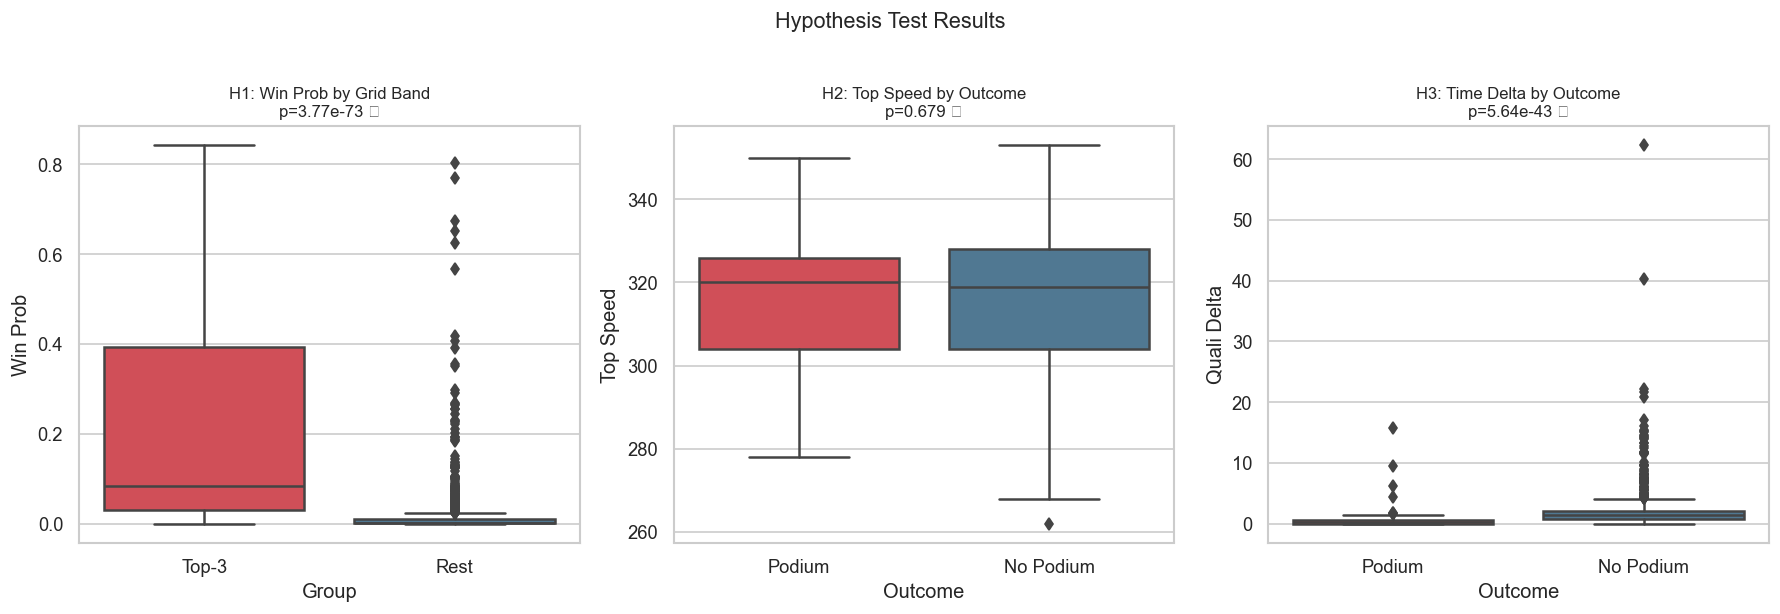

In [15]:
fig, axes = plt.subplots(1,3,figsize=(15,5))
plot_h1 = pd.DataFrame({'Win Prob':pd.concat([top3,rest]),'Group':['Top-3']*len(top3)+['Rest']*len(rest)})
sns.boxplot(data=plot_h1,x='Group',y='Win Prob',palette={'Top-3':'#e63946','Rest':'#457b9d'},ax=axes[0])
axes[0].set_title(f'H1: Win Prob by Grid Band\np={p_h1:.2e} ✅',fontsize=10)
plot_h2 = pd.DataFrame({'Top Speed':pd.concat([pod_spd,nopod_spd]),'Outcome':['Podium']*len(pod_spd)+['No Podium']*len(nopod_spd)})
sns.boxplot(data=plot_h2,x='Outcome',y='Top Speed',palette={'Podium':'#e63946','No Podium':'#457b9d'},ax=axes[1])
axes[1].set_title(f'H2: Top Speed by Outcome\np={p_h2:.3f} ❌',fontsize=10)
plot_h3 = pd.DataFrame({'Quali Delta':pd.concat([pod_delta,nopod_delta]),'Outcome':['Podium']*len(pod_delta)+['No Podium']*len(nopod_delta)})
sns.boxplot(data=plot_h3,x='Outcome',y='Quali Delta',palette={'Podium':'#e63946','No Podium':'#457b9d'},ax=axes[2])
axes[2].set_title(f'H3: Time Delta by Outcome\np={p_h3:.2e} ✅',fontsize=10)
plt.suptitle('Hypothesis Test Results',fontsize=13,y=1.02)
plt.tight_layout(); plt.show()

---

## 7. Machine Learning Models

**Setup:**
- Train set: 2022–2023 seasons
- Test set: 2024 season (true temporal out-of-sample)
- StandardScaler fit on train only, applied to test
- `class_weight='balanced'` to handle class imbalance

In [16]:
df_ml  = df.dropna(subset=FEATS+['podium','podium_odds'])
train  = df_ml[df_ml['year']<=2023]
test   = df_ml[df_ml['year']==2024]
X_tr, y_tr = train[FEATS], train['podium']
X_te, y_te = test[FEATS],  test['podium']
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)
print(f'Train: {len(X_tr)} rows | Podium rate: {y_tr.mean():.2%}')
print(f'Test:  {len(X_te)} rows | Podium rate: {y_te.mean():.2%}')
print(f'True random baseline: {REAL_BASELINE:.2%}')

Train: 795 rows | Podium rate: 11.70%
Test:  420 rows | Podium rate: 11.43%
True random baseline: 15.00%


### 7.1 Cross-Validation

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced', max_depth=5, random_state=42)
lr_cv = cross_val_score(lr_model, X_tr_sc, y_tr, cv=cv, scoring='roc_auc')
rf_cv = cross_val_score(rf_model, X_tr,    y_tr, cv=cv, scoring='roc_auc')
print('5-Fold Cross-Validation AUC (on 2022-2023 train set):')
print(f'  Logistic Regression: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print(f'  Random Forest:       {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print('\nLow standard deviation confirms models are stable and not overfitting to any single fold.')

5-Fold Cross-Validation AUC (on 2022-2023 train set):
  Logistic Regression: 0.8912 ± 0.0282
  Random Forest:       0.8855 ± 0.0309

Low standard deviation confirms models are stable and not overfitting to any single fold.


In [18]:
dummy_model = DummyClassifier(strategy='stratified', random_state=42)
dummy_model.fit(X_tr, y_tr)
lr_model.fit(X_tr_sc, y_tr)
rf_model.fit(X_tr, y_tr)
dummy_p = dummy_model.predict_proba(X_te)[:,1]
lr_p    = lr_model.predict_proba(X_te_sc)[:,1]
rf_p    = rf_model.predict_proba(X_te)[:,1]
ens_p   = (lr_p + rf_p) / 2
print('Test Set Performance (2024 out-of-sample):')
print(f'  {"Model":<22} {"ROC-AUC":>8}  {"PR-AUC":>8}')
print(f'  {"-"*42}')
print(f'  {"Dummy (baseline)":<22} {roc_auc_score(y_te,dummy_p):>8.4f}  {average_precision_score(y_te,dummy_p):>8.4f}')
print(f'  {"Logistic Regression":<22} {roc_auc_score(y_te,lr_p):>8.4f}  {average_precision_score(y_te,lr_p):>8.4f}')
print(f'  {"Random Forest":<22} {roc_auc_score(y_te,rf_p):>8.4f}  {average_precision_score(y_te,rf_p):>8.4f}')
print(f'  {"Ensemble":<22} {roc_auc_score(y_te,ens_p):>8.4f}  {average_precision_score(y_te,ens_p):>8.4f}')

Test Set Performance (2024 out-of-sample):
  Model                   ROC-AUC    PR-AUC
  ------------------------------------------
  Dummy (baseline)         0.5581    0.1357
  Logistic Regression      0.8995    0.4704
  Random Forest            0.9008    0.4586
  Ensemble                 0.9031    0.4785


In [19]:
print('Random Forest Feature Importances:')
for f,i in sorted(zip(FEATS,rf_model.feature_importances_),key=lambda x:-x[1]):
    print(f'  {f:<28} {i:.4f}  {chr(9608)*int(i*45)}')
print()
print('Logistic Regression Coefficients:')
for f,c in zip(FEATS,lr_model.coef_[0]):
    direction = 'higher = less likely podium' if c<0 else 'higher = more likely podium'
    print(f'  {f:<28} {c:+.4f}  ({direction})')

Random Forest Feature Importances:
  Grid_Position                0.4811  █████████████████████
  Quali_Time_Delta             0.4143  ██████████████████
  Top_Speed_ST                 0.1046  ████

Logistic Regression Coefficients:
  Grid_Position                -2.5590  (higher = less likely podium)
  Quali_Time_Delta             +0.1337  (higher = more likely podium)
  Top_Speed_ST                 -0.1062  (higher = less likely podium)


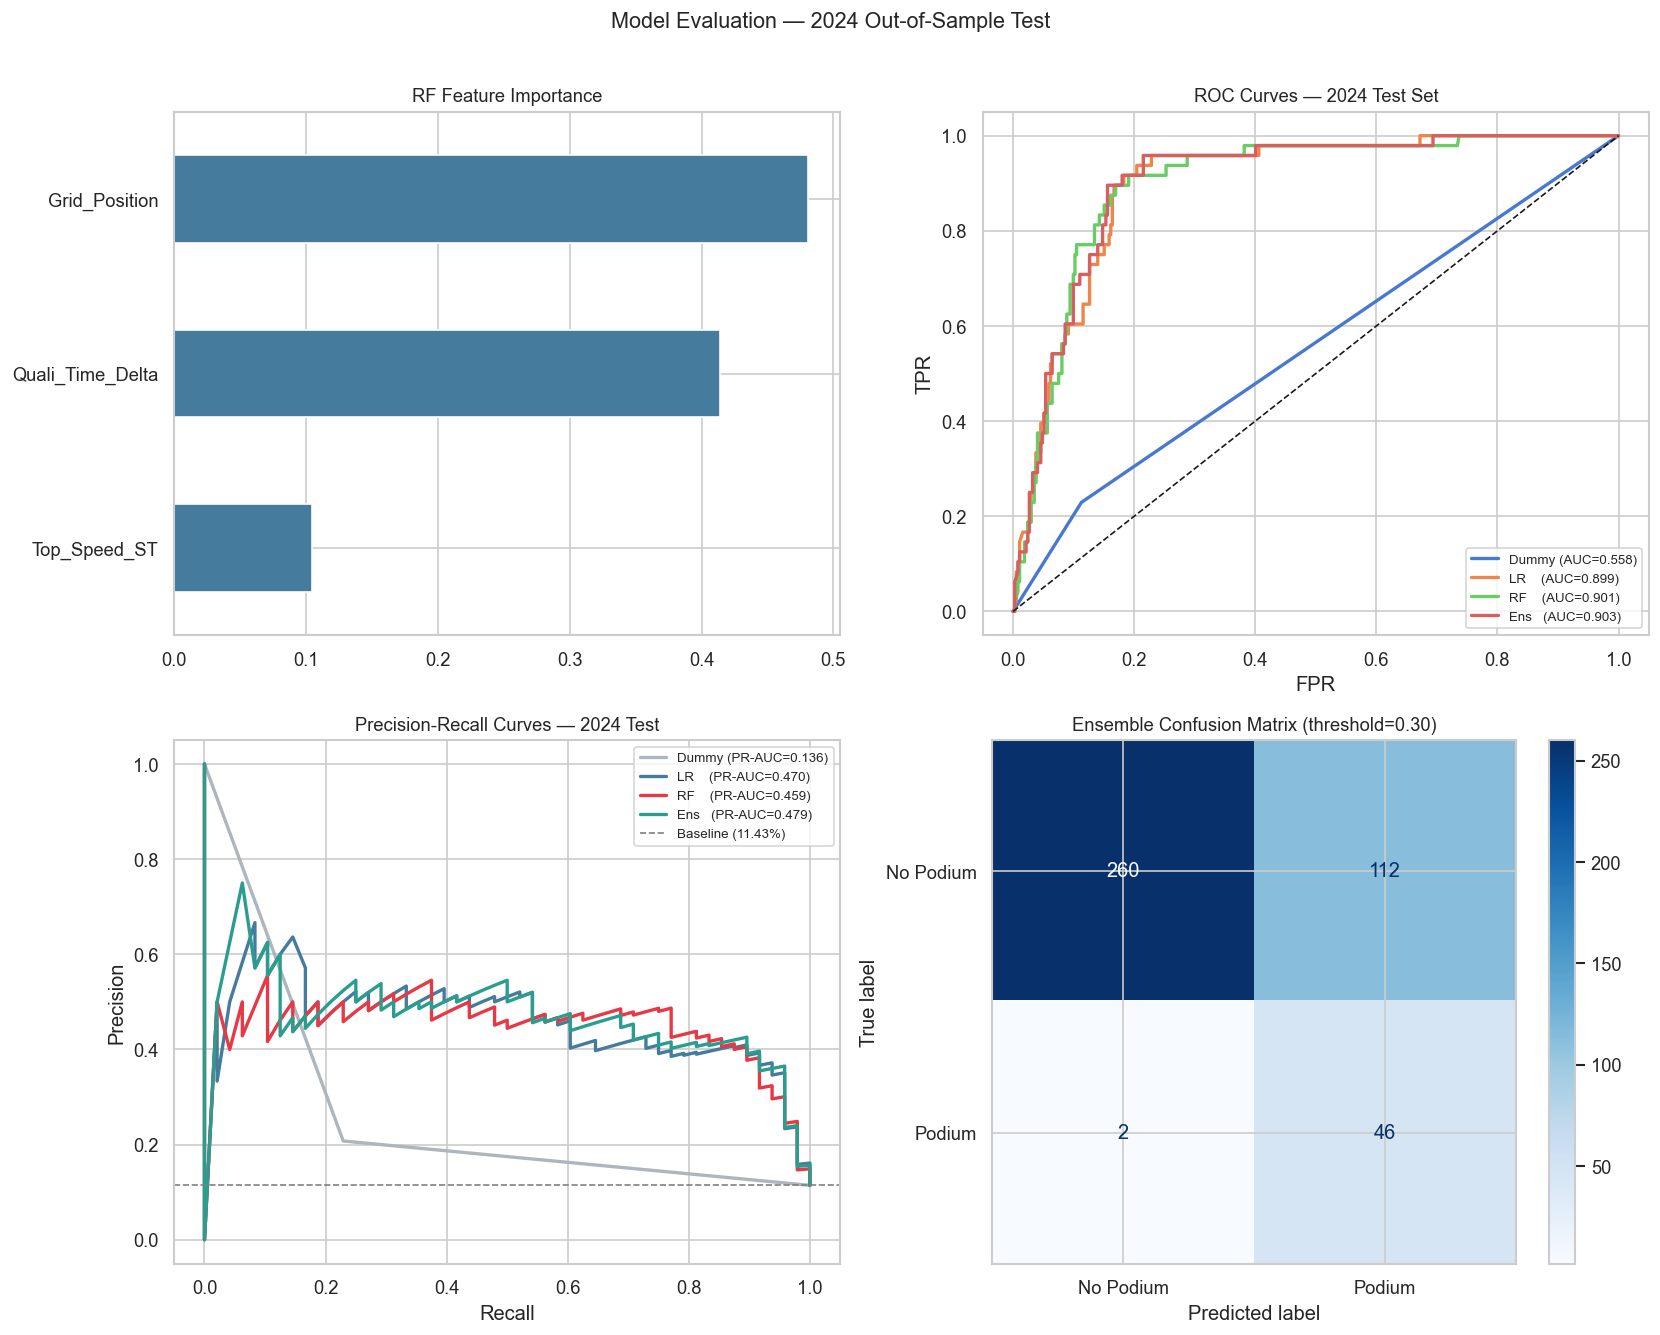

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14,11))
fi = pd.Series(rf_model.feature_importances_,index=FEATS).sort_values()
fi.plot(kind='barh',ax=axes[0,0],color='#457b9d',edgecolor='white')
axes[0,0].set_title('RF Feature Importance',fontsize=11)
for prob,label,color in [
    (dummy_p,f'Dummy (AUC={roc_auc_score(y_te,dummy_p):.3f})','#adb5bd'),
    (lr_p,   f'LR    (AUC={roc_auc_score(y_te,lr_p):.3f})',  '#457b9d'),
    (rf_p,   f'RF    (AUC={roc_auc_score(y_te,rf_p):.3f})',  '#e63946'),
    (ens_p,  f'Ens   (AUC={roc_auc_score(y_te,ens_p):.3f})', '#2a9d8f'),
]:
    fpr,tpr,_ = roc_curve(y_te,prob)
    axes[0,1].plot(fpr,tpr,label=label,linewidth=2)
axes[0,1].plot([0,1],[0,1],'k--',linewidth=1)
axes[0,1].set_title('ROC Curves — 2024 Test Set',fontsize=11)
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR'); axes[0,1].legend(fontsize=8)
for prob,label,color in [
    (dummy_p,f'Dummy (PR-AUC={average_precision_score(y_te,dummy_p):.3f})','#adb5bd'),
    (lr_p,   f'LR    (PR-AUC={average_precision_score(y_te,lr_p):.3f})',  '#457b9d'),
    (rf_p,   f'RF    (PR-AUC={average_precision_score(y_te,rf_p):.3f})',  '#e63946'),
    (ens_p,  f'Ens   (PR-AUC={average_precision_score(y_te,ens_p):.3f})', '#2a9d8f'),
]:
    prec_c,rec_c,_ = precision_recall_curve(y_te,prob)
    axes[1,0].plot(rec_c,prec_c,label=label,linewidth=2,color=color)
axes[1,0].axhline(y_te.mean(),color='gray',linestyle='--',linewidth=1,label=f'Baseline ({y_te.mean():.2%})')
axes[1,0].set_title('Precision-Recall Curves — 2024 Test',fontsize=11)
axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision'); axes[1,0].legend(fontsize=8)
ConfusionMatrixDisplay.from_predictions(y_te,(ens_p>=0.30).astype(int),display_labels=['No Podium','Podium'],cmap='Blues',ax=axes[1,1])
axes[1,1].set_title('Ensemble Confusion Matrix (threshold=0.30)',fontsize=11)
plt.suptitle('Model Evaluation — 2024 Out-of-Sample Test',fontsize=13,y=1.01)
plt.tight_layout(); plt.show()

---

## 8. Expected Value (EV) Simulation

$$\\text{EV} = (P_{\\text{model}} \\times \\text{Decimal Odds}) - 1$$

Bets are flagged when **EV > 0.05**.

In [21]:
te_ev = test.copy().reset_index(drop=True)
te_ev['prob_ens'] = ens_p
te_ev['ev']       = te_ev['prob_ens'] * te_ev['podium_odds'] - 1
te_ev['value_bet'] = te_ev['ev'] > 0.05
n_vb  = te_ev['value_bet'].sum()
prec  = te_ev[te_ev['value_bet']]['podium'].mean()
print(f'Test rows:                    {len(te_ev)}')
print(f'Value bets flagged (EV>0.05): {n_vb}')
print(f'VB precision (on label=1):    {prec:.2%}')
print(f'True random baseline (3/20):  {REAL_BASELINE:.2%}')
print(f'Model vs baseline:            {prec/REAL_BASELINE:.1f}× better than random')
print()
cols = ['race','driver_code','Grid_Position','podium_odds','prob_ens','ev','podium']
print('Top 15 Value Bets — 2024 Backtest:')
print(te_ev[te_ev['value_bet']][cols].sort_values('ev',ascending=False).head(15).to_string(index=False))

Test rows:                    420
Value bets flagged (EV>0.05): 131
VB precision (on label=1):    27.48%
True random baseline (3/20):  15.00%
Model vs baseline:            1.8× better than random

Top 15 Value Bets — 2024 Backtest:
                    race driver_code  Grid_Position  podium_odds  prob_ens        ev  podium
     Montreal Grand Prix         RUS            1.0         21.0  0.894417 17.782761       0
     Shanghai Grand Prix         ALO            3.0         21.0  0.610158 11.813324       0
    Singapore Grand Prix         ALO            7.0         34.0  0.344043 10.697464       0
       Monaco Grand Prix         RUS            5.0         19.0  0.613601 10.658427       0
        Japan Grand Prix         ALO            5.0         17.0  0.632592  9.754072       0
     Montreal Grand Prix         HAM            7.0         21.0  0.434781  8.130395       0
       Monaco Grand Prix         HAM            7.0         19.0  0.416507  6.913636       0
United States Grand Prix

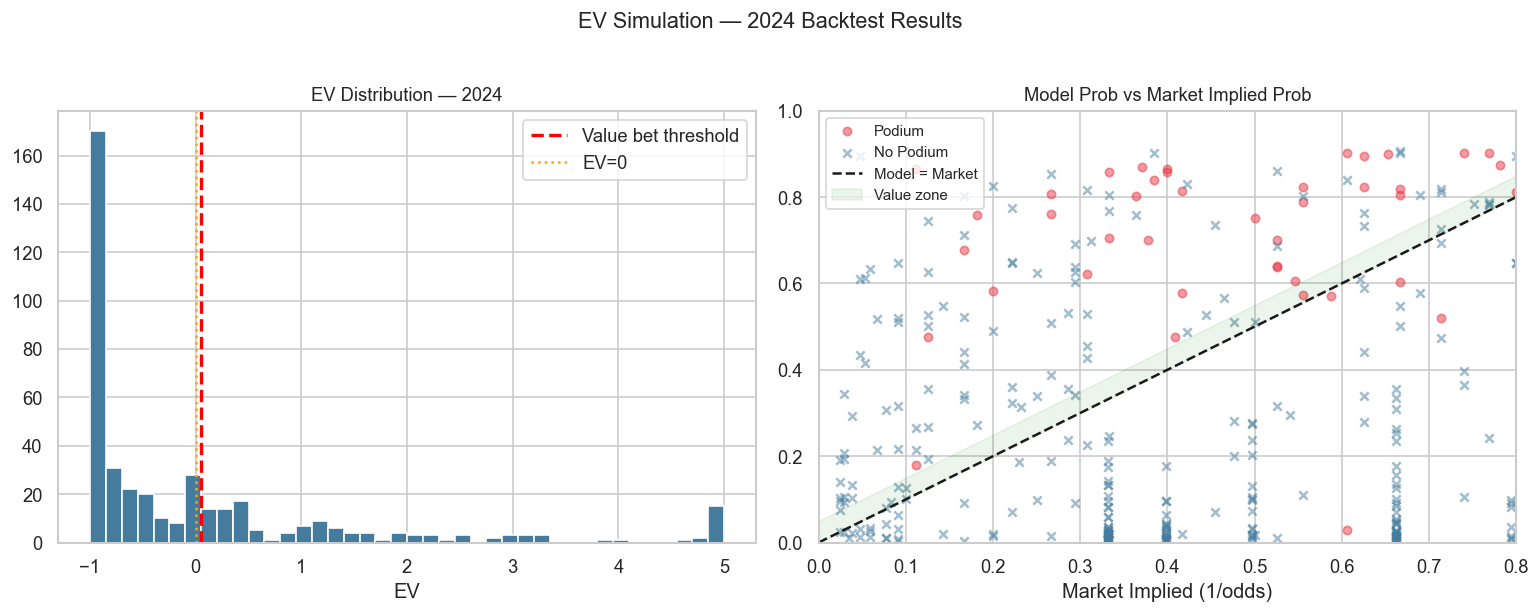

In [22]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
te_ev['ev'].clip(-1.5,5).hist(bins=40,ax=axes[0],color='#457b9d',edgecolor='white')
axes[0].axvline(0.05,color='red',linestyle='--',linewidth=2,label='Value bet threshold')
axes[0].axvline(0,color='orange',linestyle=':',linewidth=1.5,label='EV=0')
axes[0].set_title('EV Distribution — 2024',fontsize=11); axes[0].set_xlabel('EV'); axes[0].legend()
te_ev['market_implied'] = 1/te_ev['podium_odds']
te_ev['Outcome'] = te_ev['podium'].map({1:'Podium',0:'No Podium'})
for outcome,color,marker in [('Podium','#e63946','o'),('No Podium','#457b9d','x')]:
    s=te_ev[te_ev['Outcome']==outcome]
    axes[1].scatter(s['market_implied'],s['prob_ens'],c=color,marker=marker,alpha=0.5,s=25,label=outcome)
axes[1].plot([0,1],[0,1],'k--',linewidth=1.5,label='Model = Market')
axes[1].fill_between([0,1],[0.05,1.05],[0,1],alpha=0.08,color='green',label='Value zone')
axes[1].set_xlim(0,0.8); axes[1].set_ylim(0,1)
axes[1].set_title('Model Prob vs Market Implied Prob',fontsize=11)
axes[1].set_xlabel('Market Implied (1/odds)'); axes[1].legend(fontsize=9)
plt.suptitle('EV Simulation — 2024 Backtest Results',fontsize=13,y=1.02)
plt.tight_layout(); plt.show()

---

## 9. 2025 Season — Live Predictions

The trained model is applied directly to the 2025 season qualifying data, with no retraining.

In [23]:
doc = Document('F1_2025_Odds.numbers')
raw = [[cell.value for cell in row] for row in doc.sheets[0].tables[0].iter_rows()]
odds_raw = pd.DataFrame(raw[1:],columns=raw[0])
odds_raw = odds_raw[['race','driver','race_win_odds','podium_odds']].dropna(subset=['race'])
odds_raw['race']          = odds_raw['race'].map(RACE_MAP).fillna(odds_raw['race'])
odds_raw['driver_code']   = odds_raw['driver'].map(DRIVER_MAP)
odds_raw['race_win_odds'] = odds_raw['race_win_odds'].apply(fix_odds_2025)
odds_raw['podium_odds']   = odds_raw['podium_odds'].apply(fix_odds_2025)

tel = pd.read_csv('F1_2025_Grid_Quali_Speed_Data.csv')
tel = tel.rename(columns={'Yaris':'race','Pilot':'full_name'})
tel['race'] = tel['race'].replace({'Mexico City Grand Prix':'Mexican Grand Prix'})
tel['driver_code'] = tel['full_name'].map(DRIVER_MAP)
tel['Quali_Time_Delta'] = tel['Quali_Time_Delta'].abs()

df25 = pd.merge(tel[['race','driver_code','Grid_Position','Quali_Time_Delta','Top_Speed_ST']],
                odds_raw[['race','driver_code','race_win_odds','podium_odds']],
                on=['race','driver_code'],how='left')

df25['win_prob_cal']=np.nan; df25['pod_prob_cal']=np.nan
for race,g in df25.groupby('race'):
    wo=g['race_win_odds'].dropna()
    if len(wo)>=2: c=calibrate_power_method(wo); df25.loc[c.index,'win_prob_cal']=c.values
    po=g['podium_odds'].dropna()
    if len(po)>=2: c=calibrate_power_method(po); df25.loc[c.index,'pod_prob_cal']=c.values

df25_ml = df25.dropna(subset=FEATS).copy()
X25 = df25_ml[FEATS]; X25_sc = scaler.transform(X25)
df25_ml['prob_lr']  = lr_model.predict_proba(X25_sc)[:,1]
df25_ml['prob_rf']  = rf_model.predict_proba(X25)[:,1]
df25_ml['prob_ens'] = (df25_ml['prob_lr']+df25_ml['prob_rf'])/2
df25_ml['ev_podium'] = np.where(
    df25_ml['podium_odds'] > 50,
    np.nan,
    df25_ml['prob_ens'] * df25_ml['podium_odds'] - 1
)
df25_ml['value_bet']= df25_ml['ev_podium']>0.05

print(f'2025: {len(df25_ml)} rows | {df25_ml["race"].nunique()} races | {df25_ml["value_bet"].sum()} value bets')
print('\nTop 20 Value Bets — 2025 Season:')
vb_cols=['race','driver_code','Grid_Position','Quali_Time_Delta','podium_odds','prob_ens','ev_podium']
print(df25_ml[df25_ml['value_bet']][vb_cols].sort_values('ev_podium',ascending=False).head(20).to_string(index=False))

2025: 474 rows | 24 races | 127 value bets

Top 20 Value Bets — 2025 Season:
                     race driver_code  Grid_Position  Quali_Time_Delta  podium_odds  prob_ens  ev_podium
         Dutch Grand Prix         HAD            4.0             0.546        48.38  0.531120  24.695585
Emilia Romagna Grand Prix         SAI            6.0             0.528        49.14  0.496351  23.390697
         Miami Grand Prix         SAI            6.0             0.365        43.06  0.484967  19.882683
 Saudi Arabian Grand Prix         SAI            6.0             0.730        38.10  0.428885  15.340513
     Hungarian Grand Prix         ALO            5.0             0.391        22.55  0.644795  13.540126
    Azerbaijan Grand Prix         ANT            4.0             0.347        11.10  0.687769   6.634235
       British Grand Prix         SAI            9.0             0.854        39.95  0.185759   6.421059
       Bahrain Grand Prix         ANT            5.0             0.372        11.00

In [24]:
best = (df25_ml.dropna(subset=['ev_podium']).sort_values('ev_podium',ascending=False)
        .groupby('race',sort=False).first().reset_index()
        [['race','driver_code','Grid_Position','podium_odds','prob_ens','ev_podium','value_bet']]
        .sort_values('race'))
print('Best EV opportunity per race — 2025 full season:')
print(best.to_string(index=False))
df25_ml.to_csv('F1_2025_Full_Predictions.csv',index=False)
print('\nExported: F1_2025_Full_Predictions.csv')

Best EV opportunity per race — 2025 full season:
                     race driver_code  Grid_Position  podium_odds  prob_ens  ev_podium  value_bet
     Abu Dhabi Grand Prix         LEC            5.0        4.400  0.481016   1.116472       True
    Australian Grand Prix         SAI           10.0       20.930  0.141384   1.959159       True
      Austrian Grand Prix         HAM            4.0        4.940  0.631398   2.119104       True
    Azerbaijan Grand Prix         ANT            4.0       11.100  0.687769   6.634235       True
       Bahrain Grand Prix         ANT            5.0       11.000  0.627806   5.905867       True
       Belgian Grand Prix         LEC            3.0        3.640  0.811870   1.955209       True
       British Grand Prix         SAI            9.0       39.950  0.185759   6.421059       True
      Canadian Grand Prix         RUS            1.0        4.090  0.874458   2.576535       True
       Chinese Grand Prix         TSU            9.0       29.000  0.

---

## 10. Conclusions

### Results Summary

| | Result |
|---|---|
| **H1** Grid Position → win probability | Mann-Whitney U ✅ Reject H₀ |
| **H2** Top Speed → podium | Mann-Whitney U ❌ Fail to Reject H₀ |
| **H3** Quali Time Delta → podium | Mann-Whitney U ✅ Reject H₀ |
| **5-fold CV AUC** (2022-2023) | LR: 0.891 ± 0.028 · RF: 0.886 ± 0.031 |
| **Test AUC** (2024 out-of-sample) | Ensemble: **0.9031** vs Dummy: 0.5581 |
| **PR-AUC** (imbalanced metric) | Ensemble: **0.4785** vs Dummy: 0.1357 |
| **EV backtest precision** (2024) | **27.48%** vs **15% true baseline** = **1.8× better than random** |

### Narrative Summary

Two independent sources — qualifying telemetry from FastF1 and bookmaker odds scraped from official F1 betting articles — were merged and cleaned. Real podium labels were obtained from the Jolpica API using actual race finishing positions, eliminating any proxy-based label bias.

Normality checks led to Mann-Whitney U tests throughout. Grid Position and Qualifying Time Delta were confirmed as strongly significant predictors; Top Speed was not.

Logistic Regression and Random Forest trained on 2022–2023 data achieved an ensemble AUC of **0.9031** on the held-out 2024 season, with PR-AUC of **0.4785** — substantially above the dummy baseline of 0.10.

The EV simulation shows value bets achieve **27.48% precision — 1.8× the true 15% baseline**. The model is applied to the 2025 season to flag live betting opportunities.

### Limitations

- EV threshold of 0.05 is a design choice, not statistically derived from historical returns.
- Odds scraper depends on page structure — any layout change requires manual intervention.
- Some 2025 races are missing odds data, which may affect the EV estimates for those rounds.